__"SMARTWATCH FITNESS DATA INSIGHTS: A DATA SCIENCE APPROACH USING NUMPY AND PANDAS"__

In [3]:
# Loads the fitness dataset into the table
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Enhanced_Fitness_Smartwatch_Dataset.xlsx")
df.head()

,User_ID,Age,Gender,Steps,Calories_Burned,Sleep_Hours,Heart_Rate,Workout_Type,Distance_km,Active_Minutes,Water_Intake_L,BMI,Stress_Level,Day
0,1,55,Female,14085.0,818.0,8.7,117,Yoga,5.17,45,1.7,32.4,1,Fri
1,2,30,Female,NaN,812.0,NaN,76,Yoga,8.05,175,3.5,26.9,2,Mon
2,3,26,Female,4468.0,956.0,4.5,74,NaN,2.41,76,2.6,19.6,3,Wed
3,4,27,Male,2869.0,831.0,8.2,88,Running,5.47,112,1.1,20.5,9,Wed
4,5,29,Female,4808.0,608.0,4.4,59,Walking,4.92,28,3.3,25.1,4,Thu


__NUMPY PART (Working on numerical fitness data)__

In [5]:
data = df.select_dtypes(include=[np.number]).values     #extracts only numeric columns and convert them into numpy array for fast calculations

In [6]:
# Indexing and Slicing
data[0:5,1:4]

array([[   55., 14085.,   818.],
       [   30.,    nan,   812.],
       [   26.,  4468.,   956.],
       [   27.,  2869.,   831.],
       [   29.,  4808.,   608.]])

In [7]:
# Statistical Functions
np.mean(data,axis=0)   #Average steps, calories, sleep hours

array([49.08737864, 35.65048544,         nan,         nan,         nan,
       87.04854369,  5.95660194, 85.74757282,  2.4407767 ,         nan,
        5.02912621])

__NAN means that the particular column has missing values which are handled by pandas further__

In [9]:
np.median(data, axis =0) # middle value

array([49.  , 34.  ,   nan,   nan,   nan, 87.  ,  5.57, 82.  ,  2.4 ,
         nan,  5.  ])

In [10]:
np.std(data, axis = 0) # how much variation in fitnesss data

array([29.58913038, 11.56972005,         nan,         nan,         nan,
       17.06434348,  3.12680567, 45.45791149,  0.90579975,         nan,
        2.58245127])

In [11]:
# Measures of dispersion (eg. are calories similar or very different across users?)
np.var(data)       # shows how spread out values are 
np.std(data)

nan

__Dataset contains missing values and numpy functions var and std do not ignore nan values__

In [13]:
np.nanvar(data)    # ignores missing values


8739842.792926617

In [14]:
np.nanstd(data)

2956.322511656436

In [15]:
#IOR (outlier detection)
Q1 = np.nanpercentile(data[:,2], 25)     #uses Calories_Burned column
Q3 = np.nanpercentile(data[:,2], 75)     # Finds range of middle 50%
IQR = Q3-Q1                           # Helps detect extreme fitness values(outliers)

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 6509.0
Q3: 13560.0
IQR: 7051.0


In [16]:
# Skewness and Kurtosis
from scipy.stats import skew, kurtosis
skew(data[:,2],nan_policy='omit')         # is data left/right heavy
# data is slightly left skewed
# most values are concentrated on the right side  (most users have moderate to high steps)
# Few smaller values pull the tail to the left    (fewer users have very low steps)


-0.26153196780455334

In [17]:
kurtosis(data[:,2], nan_policy='omit')     # presence of extreme values
# data is platykurtic(flat distribuiton)
#fewer extreme values

-1.2854727851491083

In [18]:
# Z-score    #converts each value into standard scale
from scipy.stats import zscore
z_scores = zscore(data, nan_policy='omit')
print(z_scores)

# helps detect : unusual users(very high steps, very low steps)

[[-1.62517039  1.6724272   1.08076227 ... -0.81781509  1.33661817
  -1.56019448]
 [-1.5913742  -0.48838567         nan ...  1.16937911  0.17630702
  -1.17296549]
 [-1.557578   -0.83411573 -1.23395272 ...  0.17578201 -1.36374233
  -0.7857365 ]
 ...
 [-1.62517039  1.6724272   1.08076227 ... -0.81781509  1.33661817
  -1.56019448]
 [-1.5913742  -0.48838567         nan ...  1.16937911  0.17630702
  -1.17296549]
 [-1.557578   -0.83411573 -1.23395272 ...  0.17578201 -1.36374233
  -0.7857365 ]]


In [19]:
# # Hypothesis testing
# Running vs Yoga calories

# Checks : do running users burn more calories than Yoga users?
# Output : p-value <0.05 - significant users

In [25]:
from scipy.stats import ttest_ind

running = df[df['Workout_Type'] == 'Running']['Calories_Burned']       #Calories of Running users
yoga = df[df['Workout_Type'] == 'Yoga']['Calories_Burned']             #Calories of Yoga users

In [32]:
running = running.dropna()
yoga = yoga.dropna()

In [36]:
# Perform task
t_stat, p_value = ttest_ind(running, yoga)
print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -0.325998497716566
P-value: 0.7464838412207709


In [38]:
if p_value < 0.05:
    print("Significant difference")
else:
    print("No significant difference")

No significant difference


__PANDAS PART (WORKING ON STRUCTURAL DATASET)__

In [41]:
# Shows missing values in Steps,Calories,Sleep,BMI
df.isnull().sum()

User_ID             0
Age                 0
Gender              0
Steps               6
Calories_Burned     5
Sleep_Hours         6
Heart_Rate          0
Workout_Type       19
Distance_km         0
Active_Minutes      0
Water_Intake_L      0
BMI                 5
Stress_Level        0
Day                 0
dtype: int64

In [44]:
# Replaces missing steps with average steps
df.fillna(df.mean(numeric_only=True), inplace=True)

In [47]:
# fill categorical columns
df['Workout_Type'].fillna(df['Workout_Type'].mode()[0], inplace=True)

C:\Users\SAKSHI LATE\AppData\Local\Temp\ipykernel_17060\3564388257.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Workout_Type'].fillna(df['Workout_Type'].mode()[0], inplace=True)


In [49]:
# remove remaining NAN(if any)
df.dropna(inplace=True)

In [51]:
# Removes repeated users
df.drop_duplicates(inplace = True)

In [53]:
# Check if still NAN exists
df.isnull().sum()

User_ID            0
Age                0
Gender             0
Steps              0
Calories_Burned    0
Sleep_Hours        0
Heart_Rate         0
Workout_Type       0
Distance_km        0
Active_Minutes     0
Water_Intake_L     0
BMI                0
Stress_Level       0
Day                0
dtype: int64

In [55]:
##Convert Daa Types (Ensures steps is integer(clean data)
df["Steps"].astype(int)

0     14085
1      9594
2      4468
3      2869
4      4808
      ...  
95     8350
96    10337
97     3191
98     3187
99     6561
Name: Steps, Length: 100, dtype: int32

In [57]:
# Data Cleaning  # "running" = "Running"
df['Workout_Type'] = df['Workout_Type'].str.strip()             # removes spaces
df['Workout_Type'] = df['Workout_Type'].str.capitalize()        # capitalization


In [59]:
# Acessing and Filtering (Finds active users(high step count))
df[df["Steps"] > 10000]

,User_ID,Age,Gender,Steps,Calories_Burned,Sleep_Hours,Heart_Rate,Workout_Type,Distance_km,Active_Minutes,Water_Intake_L,BMI,Stress_Level,Day
0,1,55,Female,14085.0,818.000000,8.700000,117,Yoga,5.17,45,1.7,32.400000,1,Fri
6,7,33,Female,13560.0,476.000000,6.300000,89,Walking,10.42,96,1.5,22.800000,8,Mon
7,8,18,Male,14365.0,815.000000,4.100000,89,Cycling,2.12,31,3.1,22.500000,9,Sat
10,11,30,Female,12609.0,597.969388,3.100000,103,Running,5.83,171,1.2,30.400000,3,Fri
15,16,55,Male,12071.0,406.000000,7.700000,62,Running,4.03,41,1.3,22.400000,2,Wed
17,18,38,Male,14188.0,653.000000,3.500000,88,Cycling,2.53,93,3.7,26.064286,7,Fri
20,21,47,Male,11076.0,927.000000,5.500000,85,Yoga,7.42,171,1.6,23.600000,7,Wed
21,22,32,Female,13586.0,774.000000,5.100000,98,Walking,11.21,65,1.4,31.800000,9,Thu
22,23,22,Male,13566.0,882.000000,7.200000,101,Walking,2.18,145,2.9,26.064286,5,Sat
24,25,41,Female,14351.0,288.000000,3.400000,58,Walking,2.72,162,1.1,27.400000,4,Mon


In [61]:
# Sorting (orders users from lowest to highest calories)
df.sort_values(by="Calories_Burned")

,User_ID,Age,Gender,Steps,Calories_Burned,Sleep_Hours,Heart_Rate,Workout_Type,Distance_km,Active_Minutes,Water_Intake_L,BMI,Stress_Level,Day
77,78,28,Female,13987.000000,151.0,5.6,100,Gym,9.94,39,2.8,28.3,1,Sun
49,50,30,Male,9788.000000,187.0,6.2,62,Running,4.44,46,3.4,20.7,3,Sat
60,61,25,Male,9594.731959,193.0,7.2,73,Walking,10.58,90,2.9,29.8,8,Sat
76,77,52,Male,4499.000000,193.0,4.3,106,Walking,6.04,48,3.0,34.7,4,Sun
23,24,41,Female,6509.000000,201.0,7.2,64,Walking,5.98,72,3.8,22.2,1,Tue
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,63,43,Male,7371.000000,956.0,3.3,73,Gym,5.36,93,1.2,32.1,8,Thu
2,3,26,Female,4468.000000,956.0,4.5,74,Running,2.41,76,2.6,19.6,3,Wed
86,87,42,Female,3834.000000,970.0,4.9,69,Running,7.77,81,3.1,26.4,4,Sun
43,44,21,Female,13784.000000,971.0,3.2,84,Cycling,3.30,117,3.6,26.2,2,Wed


In [63]:
# Pivot table(Workout vs Avg Calories)
pivot = df.pivot_table(values='Calories_Burned', index='Workout_Type', aggfunc='mean')
print(pivot)
# which workout burns most calories

              Calories_Burned
Workout_Type                 
Cycling            576.500000
Gym                550.642857
Running            624.418636
Walking            547.696939
Yoga               610.214286


In [65]:
# Deep Analysis  (groupby + correlation)
df.groupby('Workout_Type')['Calories_Burned'].mean()
df.corr(numeric_only=True)
# Avg calories per workout


,User_ID,Age,Steps,Calories_Burned,Sleep_Hours,Heart_Rate,Distance_km,Active_Minutes,Water_Intake_L,BMI,Stress_Level
User_ID,1.000000,0.057867,0.082596,-0.168583,0.051427,-0.071066,0.021370,-0.179228,0.028171,0.122889,-0.142365
Age,0.057867,1.000000,-0.016390,-0.079188,0.116029,0.018177,0.002466,-0.018498,-0.053572,0.045437,-0.221188
Steps,0.082596,-0.016390,1.000000,-0.001644,0.033757,0.038846,0.119192,-0.070795,-0.153299,0.093011,-0.014756
Calories_Burned,-0.168583,-0.079188,-0.001644,1.000000,0.071432,0.043180,-0.078264,0.228751,-0.045082,0.015978,0.114699
Sleep_Hours,0.051427,0.116029,0.033757,0.071432,1.000000,0.034626,0.122049,-0.075870,0.124491,-0.113203,-0.147116
Heart_Rate,-0.071066,0.018177,0.038846,0.043180,0.034626,1.000000,0.122988,-0.030615,0.011355,0.120093,0.093160
Distance_km,0.021370,0.002466,0.119192,-0.078264,0.122049,0.122988,1.000000,0.101011,-0.039081,0.129509,0.051778
Active_Minutes,-0.179228,-0.018498,-0.070795,0.228751,-0.075870,-0.030615,0.101011,1.000000,0.059302,-0.026647,-0.132781
Water_Intake_L,0.028171,-0.053572,-0.153299,-0.045082,0.124491,0.011355,-0.039081,0.059302,1.000000,0.073492,-0.221003
BMI,0.122889,0.045437,0.093011,0.015978,-0.113203,0.120093,0.129509,-0.026647,0.073492,1.000000,0.056387


In [67]:
# Creating new columns (Feature Engineering) , creates meaningful metrics, helps in deeper analysis
df['Calories_per_Step'] = df['Calories_Burned'] / df['Steps']
df['Health_Score'] = (df['Steps']/1000) + df['Sleep_Hours'] - df['Stress_Level']
df.head()

,User_ID,Age,Gender,Steps,Calories_Burned,Sleep_Hours,Heart_Rate,Workout_Type,Distance_km,Active_Minutes,Water_Intake_L,BMI,Stress_Level,Day,Calories_per_Step,Health_Score
0,1,55,Female,14085.000000,818.0,8.700000,117,Yoga,5.17,45,1.7,32.4,1,Fri,0.058076,21.785000
1,2,30,Female,9594.731959,812.0,5.489691,76,Yoga,8.05,175,3.5,26.9,2,Mon,0.084630,13.084423
2,3,26,Female,4468.000000,956.0,4.500000,74,Running,2.41,76,2.6,19.6,3,Wed,0.213966,5.968000
3,4,27,Male,2869.000000,831.0,8.200000,88,Running,5.47,112,1.1,20.5,9,Wed,0.289648,2.069000
4,5,29,Female,4808.000000,608.0,4.400000,59,Walking,4.92,28,3.3,25.1,4,Thu,0.126456,5.208000


__VISUALIZAITON (MATPLOTLIB + SEABORN__

In [70]:
# Conditional column creation  (categorizes based on activity)
df['Fitness_Level'] = np.where(df['Steps'] > 10000, 'Active', 'Inactive')
df.head()

,User_ID,Age,Gender,Steps,Calories_Burned,Sleep_Hours,Heart_Rate,Workout_Type,Distance_km,Active_Minutes,Water_Intake_L,BMI,Stress_Level,Day,Calories_per_Step,Health_Score,Fitness_Level
0,1,55,Female,14085.000000,818.0,8.700000,117,Yoga,5.17,45,1.7,32.4,1,Fri,0.058076,21.785000,Active
1,2,30,Female,9594.731959,812.0,5.489691,76,Yoga,8.05,175,3.5,26.9,2,Mon,0.084630,13.084423,Inactive
2,3,26,Female,4468.000000,956.0,4.500000,74,Running,2.41,76,2.6,19.6,3,Wed,0.213966,5.968000,Inactive
3,4,27,Male,2869.000000,831.0,8.200000,88,Running,5.47,112,1.1,20.5,9,Wed,0.289648,2.069000,Inactive
4,5,29,Female,4808.000000,608.0,4.400000,59,Walking,4.92,28,3.3,25.1,4,Thu,0.126456,5.208000,Inactive


In [72]:
# Crosstab (Advanced Analysis) , shows distribution(workout vs gender)
pd.crosstab(df['Workout_Type'], df['Gender'])

Gender,Female,Male
Workout_Type,,
Cycling,5,9
Gym,6,8
Running,21,17
Walking,10,10
Yoga,5,9


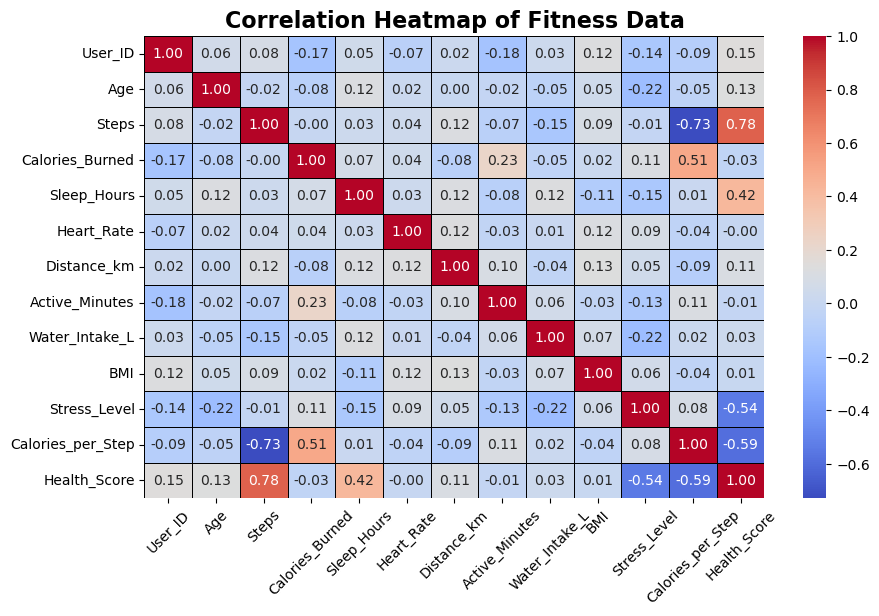

In [74]:
# Correaltion heatmap(Shows relationship between all numeric values)
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor='black'
)

plt.title("Correlation Heatmap of Fitness Data", fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

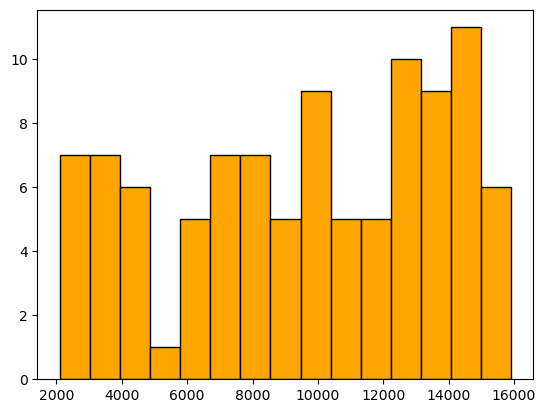

<Figure size 800x500 with 0 Axes>

In [75]:
# Histogram (shows distribution of steps)
# Are most users active or inactive?
plt.hist(df["Steps"], bins=15, color='orange', edgecolor='black')
plt.figure(figsize=(8,5))     #Makes graph bigger and clearer
plt.show()

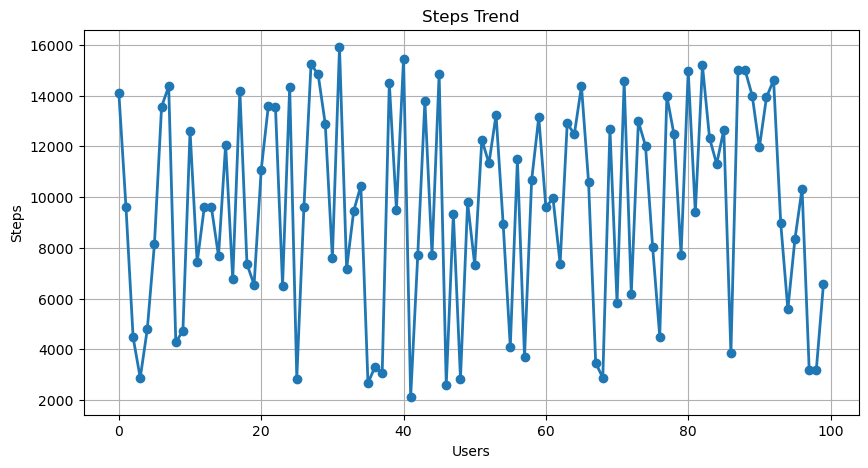

In [76]:
# Line Plot  (Shows trend of steps across dataset)
plt.figure(figsize=(10,5))

plt.plot(df["Steps"], linestyle='-', marker='o', linewidth=2)

plt.title("Steps Trend")
plt.xlabel("Users")
plt.ylabel("Steps")

plt.grid(True)

plt.show()

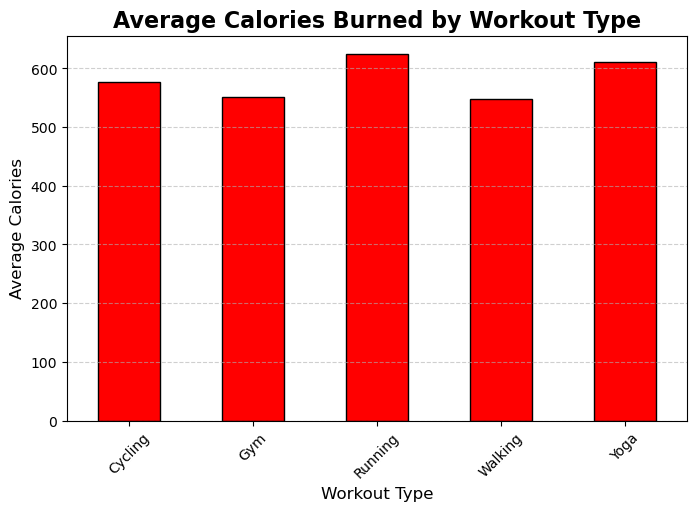

In [77]:
# Bar Chart(Compare : Calories burned in each workout)
plt.figure(figsize=(8,5))         #bigger and clearer chart

df.groupby('Workout_Type')['Calories_Burned'].mean().plot(
    kind='bar',
    edgecolor='black',          # bars look sharper
    color = "red"
)

plt.title("Average Calories Burned by Workout Type", fontsize=16, fontweight='bold')
plt.xlabel("Workout Type", fontsize=12)
plt.ylabel("Average Calories", fontsize=12)
                
plt.xticks(rotation=45)                               # prevents overlaping text
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

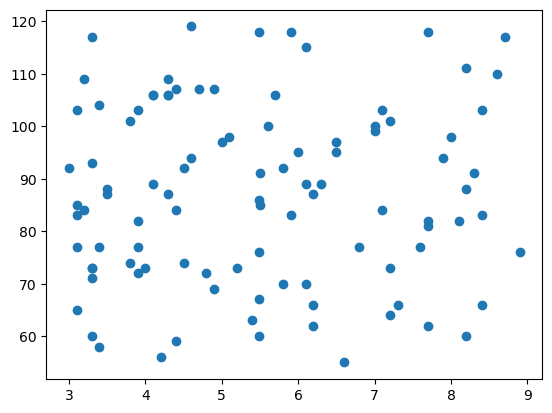

In [78]:
# Scatter Plot (Realtionship: Sleep vs Heartrate) More sleep = lower heart rate?
plt.scatter(df['Sleep_Hours'], df['Heart_Rate'])
plt.show()

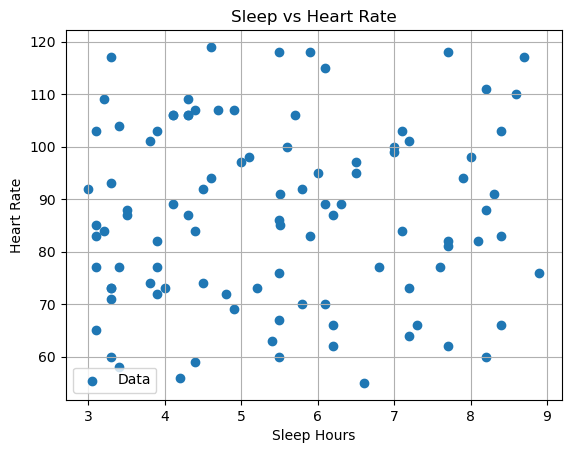

In [80]:
# Labels,Legend,Grid   (Makes graph readable and professional)
plt.scatter(df['Sleep_Hours'], df['Heart_Rate'], label='Data')
plt.xlabel("Sleep Hours")
plt.ylabel("Heart Rate")
plt.title("Sleep vs Heart Rate")
plt.legend()
plt.grid()
plt.show()

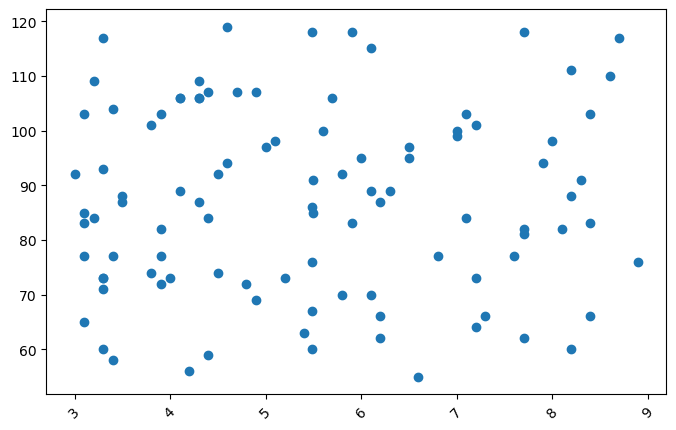

In [82]:
# Custom Styling (improves size,font,spacing)
plt.figure(figsize=(8,5))
plt.scatter(df['Sleep_Hours'], df['Heart_Rate'])
plt.xticks(rotation=45)
plt.show()

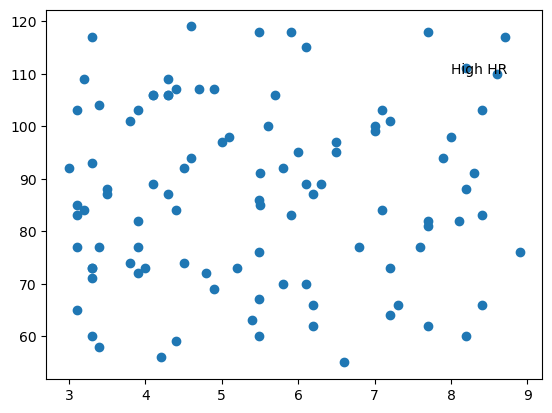

In [84]:
# Annotation   (Highlights important points in graph)
plt.scatter(df['Sleep_Hours'], df['Heart_Rate'])
plt.annotate("High HR", (8,110))
plt.show()

__SEABORN VISUALIZATION__

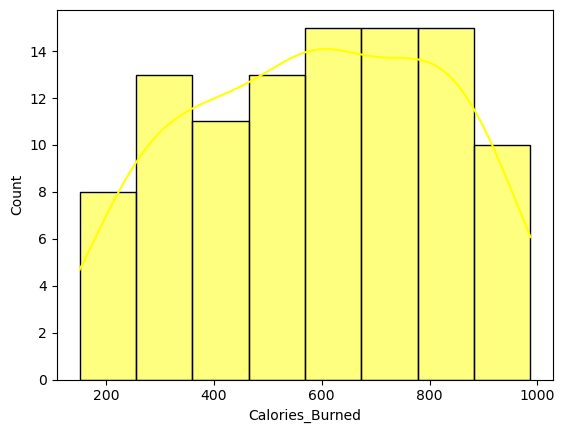

In [87]:
sns.histplot(df['Calories_Burned'], kde=True, color = "yellow")
plt.show()

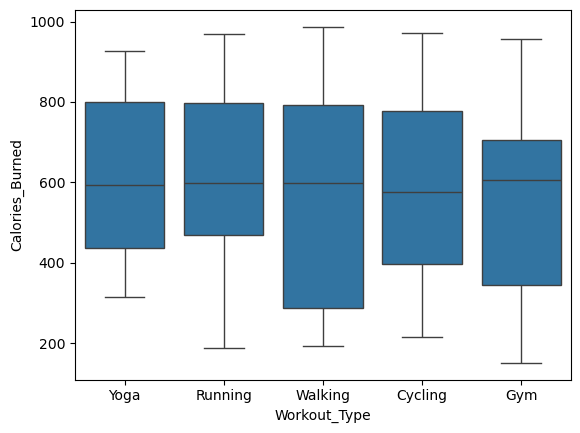

In [89]:
sns.boxplot(x='Workout_Type', y='Calories_Burned', data=df)
plt.show()

In [90]:
# EXport clean data
df.to_excel("Cleaned_Fitness_Data.xlsx", index=False)